# Ejercicio 3: construcción de la matriz de proyección binaria

En este ejercicio se reúnen las máscaras correspondientes a distintos rayos en una única matriz de proyección $A$. Cada máscara se vectoriza por filas y se incorpora como una fila de la matriz.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

## a) y b) Construcción de la matriz de proyección e identificación de los rayos

La función `matriz_proyeccion` recibe el tamaño de la imagen y una lista de direcciones. Para cada dirección $(\alpha,\beta)$, calcula todos los valores posibles de $s=\alpha i+\beta j$, elimina los repetidos y los ordena de menor a mayor. Luego construye la máscara correspondiente a cada valor de $s$, la vectoriza y la agrega como una fila de $A$. Al mismo tiempo, guarda el par $((\alpha,\beta),s)$ asociado a cada fila para poder identificar el rayo correspondiente.


In [2]:
def mascara_rayo(n, direccion, s):

    matriz = np.array([[0] * n for _ in range(n)])      # creamos una matriz de n x n de ceros

    for i in range(0, n):      
        for j in range(0, n):
            if direccion[0] * i + direccion[1] * j == s:        # comprobamos si el píxel (i, j) pertenece al rayo
                matriz[i, j] = 1        # si pertenece al rayo, marcamos esa posición con un 1

    return matriz       # devolvemos la máscara del rayo


def matriz_proyeccion(n, direcciones):

    matriz = []     # acá vamos a guardar los vectores de todas las máscaras
    rayo = []       # acá vamos a guardar los pares de s y (alfa, beta) de cada rayo

    for direccion in direcciones:

        valores_s = []      # acá guardamos todos los valores posibles de s para la dirección actual

        # recorremos todos los píxeles
        for i in range(n):
            for j in range(n):
                valores_s.append(direccion[0] * i + direccion[1] * j)       # calculamos el valor de s que le corresponde al píxel (i, j) para esta dirección

        valores_s = sorted(set(valores_s))      # eliminamos los valores repetidos de s y los ordenamos de menor a mayor

        for s in valores_s:

            rayo.append((tuple(direccion), s))

            mascara = mascara_rayo(n, direccion, s)     # generamos la máscara de este rayo particular
            matriz.append(mascara.reshape(-1))      # convertimos la máscara de n x n en un vector y lo agregamos como una nueva fila

    return np.array(matriz) , rayo

## c) Construcción de la matriz con rayos horizontales y verticales

Se aplica la función con $n=8$ y las direcciones $(1,0)$ y $(0,1)$. La primera dirección genera 8 rayos horizontales y la segunda genera 8 rayos verticales, por lo que se espera obtener un total de 16 rayos.


In [3]:
direcciones = [(1, 0), (0, 1)]

A, rayos = matriz_proyeccion(8, direcciones)

print(len(rayos))       # cantidad de rayos
print(A.shape)     #dimensiones de la matriz

16
(16, 64)


Se obtuvieron 16 rayos y una matriz de dimensiones $(16,64)$. Cada una de sus 16 filas representa un rayo, mientras que sus 64 columnas corresponden a los 64 píxeles de la imagen. Por lo tanto, se verifica que $A\in\mathbb{R}^{16\times64}$.


## d) Interpretación y visualización de la matriz de proyección

Cada fila de $A$ representa la máscara vectorizada de un rayo: los unos indican los píxeles atravesados y los ceros los píxeles que no pertenecen a ese rayo. Cada columna representa un píxel del fantoma y muestra cuáles de los rayos lo atraviesan. La matriz contiene una gran cantidad de ceros porque cada rayo selecciona solamente 8 de los 64 píxeles de la imagen. Por lo tanto, la mayoría de sus elementos indican que un determinado rayo no atraviesa un determinado píxel.


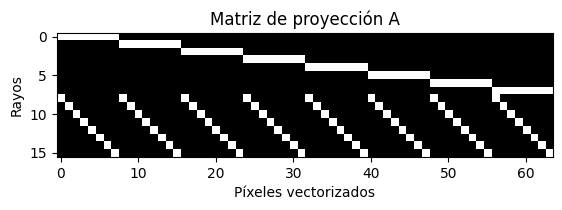

In [4]:
plt.imshow(A, cmap="gray")
plt.title("Matriz de proyección A")
plt.xlabel("Píxeles vectorizados")
plt.ylabel("Rayos")
plt.show()

## e) Cálculo y verificación de las mediciones

Se calcula el vector de mediciones mediante $b=Ax_{\text{fantoma}}$. Como las primeras ocho filas de $A$ corresponden a rayos horizontales, las primeras ocho componentes de $b$ deben coincidir con las sumas de las filas de `X_fantoma`. Las ocho componentes restantes corresponden a rayos verticales y deben coincidir con las sumas de sus columnas.


In [17]:
X_fantoma = np.array([
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
[0.0, 0.0, 0.8, 0.3, 0.3, 0.3, 0.0, 0.0],
[0.0, 0.8, 0.8, 0.8, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.8, 0.3, 0.3, 0.3, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.3, 0.5, 0.3, 0.0],
[0.0, 0.3, 0.3, 0.3, 0.5, 0.5, 0.5, 0.0],
[0.0, 0.0, 0.3, 0.3, 0.3, 0.5, 0.0, 0.0],
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
], dtype=float)

x_fantoma = X_fantoma.reshape(-1)

b = A @ x_fantoma

if (np.allclose(X_fantoma.sum(axis=1), b[:8]) and np.allclose(X_fantoma.sum(axis=0), b[8:])):
    print("sip")

sip


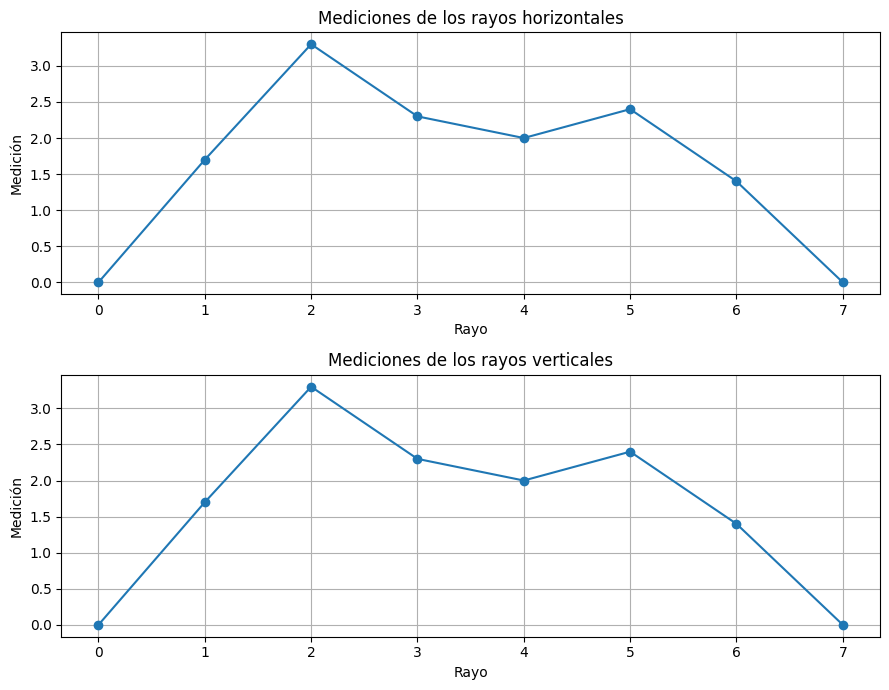

In [18]:
fig, ax = plt.subplots(2, 1, figsize=(9, 7))

# Primeras ocho componentes: sumas de las filas
ax[0].plot(range(8), b[:8], marker="o")
ax[0].set_title("Mediciones de los rayos horizontales")
ax[0].set_xlabel("Rayo")
ax[0].set_ylabel("Medición")
ax[0].grid()

# Últimas ocho componentes: sumas de las columnas
ax[1].plot(range(8), b[8:], marker="o")
ax[1].set_title("Mediciones de los rayos verticales")
ax[1].set_xlabel("Rayo")
ax[1].set_ylabel("Medición")
ax[1].grid()

plt.tight_layout()
plt.show()

La comparación numérica confirma que las primeras ocho componentes de $b$ coinciden con las sumas de las filas del fantoma y que las ocho restantes coinciden con las sumas de sus columnas. Los dos gráficos muestran estas mediciones como señales unidimensionales, donde cada punto representa la atenuación total registrada por uno de los rayos.
